# Решение тестового задания 

Что буду делать: смотрим данные, делаем текстовый поиск, а потом добавляем к нему то, что найдется в данных, и каждый раз проверяем, стало ли лучше

In [1]:
import re
from functools import lru_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import linear_kernel, haversine_distances
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import resample
import pymorphy3
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

np.random.seed(42)

## Данные

In [ ]:
train = pd.read_parquet("../data/train.parquet")
bq = pd.read_parquet("../data/benchmark_queries.parquet")
bi = pd.read_parquet("../data/benchmark_items.parquet", columns=["item_id", "item_category_id", "item_microcat_id", "item_location_id"])

print(train.shape, bq.shape, bi.shape)
train.head(3)

(497673, 19) (2452, 6) (189212, 4)


,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,39.712818145751953,652430,54.629230499267578,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,44.051009999999998,640860,56.273389999999999,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,30.128784180000000,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114


In [3]:
train.isna().sum()[lambda s: s > 0]

item_rating_reviews_count    19211
item_rating                  28232
item_longitude                   4
item_latitude                    4
dtype: int64

Пропуски есть только в рейтинге и числе отзывов

## Что такое запрос и сколько у него правильных ответов

In [4]:
print("search_category в train:", train.search_category.value_counts().to_dict())
print("search_category в бенчмарке:", bq.search_category.value_counts().to_dict())
print("поисков с доставкой: train", int(train.search_is_delivery_search.sum()), "из", len(train),
      "| бенчмарк", int(bq.search_is_delivery_search.sum()), "из", len(bq))
print("кликнутые объявления не из категории 114 в train:", int((train.item_category_id != 114).sum()), "из", len(train))
print("объявления не из категории 114 в корпусе:", int((bi.item_category_id != 114).sum()), "из", len(bi))

search_category в train: {114: 497635, 0: 34, 81: 2, 10: 2}
search_category в бенчмарке: {114: 2230, 0: 222}
поисков с доставкой: train 12 из 497673 | бенчмарк 0 из 2452
кликнутые объявления не из категории 114 в train: 15 из 497673
объявления не из категории 114 в корпусе: 1876 из 189212


Что тут видно:
- Доставка: в бенчмарке ни одного такого запроса, признак можно убрать
- Категория объявления: в train кликнуты почти только объявления из категории 114, а в корпусе бенчмарка около 1% объявлений не из неё. Их почти никто не выбирает, значит, их можно исключать из кандидатов
- Категория поиска: в train она почти всегда 114, а вот в бенчмарке у 222 запросов она равна 0. Учиться на 34 строках train нечему

Запросом буду считать тройку: текст + локация + фильтры

уникальных запросов: 354459 | в среднем объявлений на запрос: 1.4


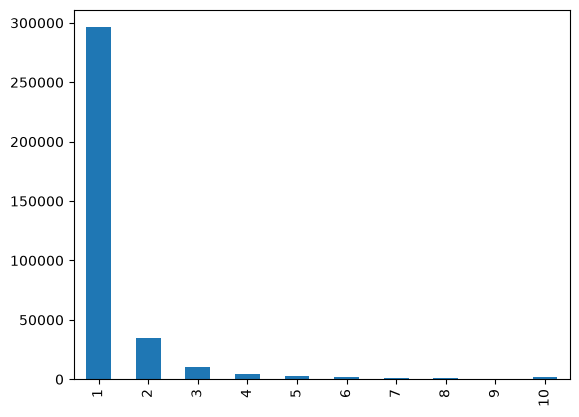

In [5]:
qcols = ["search_query", "search_location_id", "search_infm_params_text"]
sizes = train.groupby(qcols).size()
print("уникальных запросов:", len(sizes), "| в среднем объявлений на запрос:", round(sizes.mean(), 2))
sizes.clip(upper=10).value_counts().sort_index().plot.bar()
plt.show()

В среднем 1.4 объявления на запрос, у большинства ровно одно. В задании написано одно-два, так что "запрос" я определил правильно

## Подкатегории

In [6]:
print("подкатегорий в train:", train.item_microcat_id.nunique(), "| в бенчмарке:", bi.item_microcat_id.nunique())
print("подкатегорий train, которых нет в корпусе:", len(set(train.item_microcat_id) - set(bi.item_microcat_id)))

подкатегорий в train: 212 | в бенчмарке: 752


подкатегорий train, которых нет в корпусе: 6


Получается, что подкатегория сильно важнее, чем сама категория(логично конечно, но стоило проверить)

## Тексты запросов

In [7]:
print(train.search_query.str.split().str.len().describe())
seen = bq.search_query.str.lower().isin(set(train.search_query.str.lower()))
print("запросов бенчмарка, чей текст есть в train:", round(seen.mean(), 2))

count    497673.000000
mean          2.339287
std           1.067237
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          17.000000
Name: search_query, dtype: float64


запросов бенчмарка, чей текст есть в train: 0.37


## Локация

In [8]:
print("клик в той же локации, что и поиск:", round((train.search_location_id == train.item_location_id).mean(), 3))
print("локации запросов бенчмарка, которые есть у объявлений корпуса:",
      round(bq.search_location_id.isin(set(bi.item_location_id)).mean(), 3))

клик в той же локации, что и поиск: 0.831
локации запросов бенчмарка, которые есть у объявлений корпуса: 0.826


83% кликов приходятся на объявления из той же локации. Получается, что это самый сильный признак. Но не 100%, поэтому жестких фильтров не будет

## Есть ли слова запроса в тексте объявления

In [9]:
def words(s):
    return set(re.findall(r"\w+", str(s).lower()))

sample = train.sample(2000, random_state=1)
in_title = sample.apply(lambda r: len(words(r.search_query) & words(r.item_title_raw)) > 0, axis=1)
in_desc = sample.apply(lambda r: len(words(r.search_query) & words(r.item_description_raw)) > 0, axis=1)
print("в заголовке:", in_title.mean(), "| в описании:", in_desc.mean())

в заголовке: 0.7295 | в описании: 0.791


В заголовке слово из запроса есть в 70% случаев, в описании в 80%. Остальное, скорее всего, разные формы слов, что можно попробовать решить лемматизацией

## Как проверяю качество

- берем 1000 случайных запросов, их правильные ответы - объявления, по которым по ним кликали
- корпус для поиска - эти правильные объявления + случайные другие из train
- всё что учится по кликам (подкатегории, центры локаций), считаю только по остальным запросам, чтобы не было утечки

In [10]:
train["lat"] = pd.to_numeric(train.item_latitude, errors="coerce").astype("float32")
train["lon"] = pd.to_numeric(train.item_longitude, errors="coerce").astype("float32")
train["qkey"] = train.search_query + "|" + train.search_location_id.astype(str) + "|" + train.search_infm_params_text

_, val_keys = train_test_split(train.qkey.unique().to_numpy(), test_size=1000, random_state=42)
is_val = train.qkey.isin(val_keys)

val = train[is_val].drop_duplicates("qkey").reset_index(drop=True)
pos_ids = train[is_val].groupby("qkey").item_id.apply(set)
print("валидационных запросов:", len(val), "| правильных пар:", is_val.sum())

валидационных запросов: 1000 | правильных пар: 1563


In [11]:
# корпус: правильные объявления + случайные остальные
N_CORPUS = 190000
all_ids = train.item_id.unique().to_numpy()
right_ids = set(train.item_id[is_val])
others = resample(all_ids, n_samples=N_CORPUS, replace=False, random_state=42)
keep = right_ids | set(others[: N_CORPUS - len(right_ids)])

corpus = train[train.item_id.isin(keep)].drop_duplicates("item_id").reset_index(drop=True)
print("объявлений в корпусе:", len(corpus))

# положительные ответы как номера строк корпуса
id2idx = pd.Series(np.arange(len(corpus)), index=corpus.item_id.values)
pos = [set(id2idx[list(pos_ids[k])].values) for k in val.qkey]

# клики: запрос и кликнутое объявление (его подкатегория и координаты). По ним учатся наивный байес и центры локаций
clicks = train[["search_query", "search_location_id", "search_infm_params_text", "item_id", "qkey", "item_microcat_id", "lat", "lon"]]

объявлений в корпусе: 189238


## Текстовый поиск

Первую версию отправил на TF-IDF, получил 0.786. Решил попробовать BM25, он ещё и учитывает длину объявления, не только частоту слова. Каждое слово привожу к начальной форме. Заголовок беру три раза, чтобы он был важнее описания. Слова, которые встречаются больше чем в половине объявлений, выкидываю параметром `max_df`, они ничего не различают

In [ ]:
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=None)
def lemma(w):
    # pymorphy медленный, а слова сильно повторяются, поэтому запоминаю результат для каждого слова
    if re.fullmatch(r"[а-я]+", w):
        return morph.parse(w)[0].normal_form
    return w

def tokenize(text):
    return [lemma(w) for w in re.findall(r"[a-zа-я0-9]+", text.replace("ё", "е"))]


def item_text(df):
    desc = df.item_description_raw.fillna("")
    return (df.item_title_raw + " ") * 3 + df.item_infm_params_text + " " + desc

def make_vectorizer():
    return CountVectorizer(tokenizer=tokenize, token_pattern=None, min_df=2, max_df=0.5, dtype=np.float32)

def bm25_weights(M, k1=1.5, b=0.75):
    M = M.tocsr().astype(np.float32)
    n_docs = M.shape[0]
    doc_len = np.asarray(M.sum(1)).ravel()
    df = np.bincount(M.indices, minlength=M.shape[1])
    idf = np.log(1 + (n_docs - df + 0.5) / (df + 0.5)).astype(np.float32)
    doc_norm = (k1 * (1 - b + b * doc_len / doc_len.mean())).astype(np.float32)
    tf = M.data
    norm = tf + np.repeat(doc_norm, np.diff(M.indptr))
    M.data = (tf * (k1 + 1) / norm * idf[M.indices]).astype(np.float32)
    return M

def item_stats(df):
    # рейтинг и цена рваные: у рейтинга бывают настоящие нули, у цены дикие выбросы и отрицательные значения
    rating = df.item_rating.fillna(df.item_rating.median())
    price = pd.to_numeric(df.item_price, errors="coerce").clip(lower=0)
    log_price = np.log1p(price.fillna(price.median()))
    log_reviews = np.log1p(df.item_rating_reviews_count.fillna(0))
    return rating.values.astype(np.float32), log_price.values.astype(np.float32), log_reviews.values.astype(np.float32)

In [13]:
corpus["text"] = item_text(corpus)

cv = make_vectorizer()
X = bm25_weights(cv.fit_transform(corpus.text))
print(X.shape)

(189238, 175248)


## Признаки пары

Дальше для каждого запроса модель будет оценивать каждое объявление корпуса. Для этого для пары (запрос, объявление) считаю несколько чисел:

- `text`: сходство слов запроса с текстом объявления, нормированное так, чтобы лучшее объявление для запроса имело 1
- `text_raw`: то же сходство без нормировки (показывает, насколько хорошо совпало в абсолюте);
- `text_filters`: сходство фильтров запроса с текстом объявления
- `same_loc`: 1, если объявление в той же локации, что и поиск
- `near` и `log_km`: расстояние от центра локации поиска до объявления, как `exp(-км / 100)` и как `log(1 + км)`
- `nb`: вероятность подкатегории объявления при таких словах запроса
- `rating`, `log_price`, `log_reviews`: рейтинг объявления, логарифм цены и логарифм числа отзывов

In [ ]:
ALPHA = 0.1

def learn_prior(part, alpha):
    cvq = CountVectorizer(tokenizer=tokenize, token_pattern=None, binary=True)
    Xw = cvq.fit_transform(part.search_query)
    nb = MultinomialNB(alpha=alpha).fit(Xw, part.item_microcat_id)
    return cvq, nb

def prior_for(cvq, nb, queries):
    # вероятность каждой подкатегории для запроса, нормирую так, чтобы лучшая = 1
    pr = nb.predict_proba(cvq.transform(queries))
    pr = pr / pr.max(axis=1, keepdims=True)
    return np.hstack([pr, np.zeros((len(pr), 1))]) # последний столбец для подкатегорий, которых не было в train

def corpus_mc(nb, microcats):
    # номер подкатегории в столбцах вероятностей (неизвестная = последний столбец)
    idx = pd.Index(nb.classes_).get_indexer(microcats)
    return np.where(idx < 0, len(nb.classes_), idx)

def get_centers(part):
    # центр локации поиска = медиана координат объявлений, которые в ней кликали
    g = part.groupby("search_location_id")[["lat", "lon"]].median()
    return {loc: (a, b) for loc, a, b in zip(g.index, g.lat, g.lon)}

train_part = clicks[~is_val]
cvq, nb = learn_prior(train_part, ALPHA)
prior = prior_for(cvq, nb, val.search_query)

lat = pd.to_numeric(corpus.item_latitude, errors="coerce")
lon = pd.to_numeric(corpus.item_longitude, errors="coerce")
rating, log_price, log_reviews = item_stats(corpus)
c = dict(X=X, loc=corpus.item_location_id.values, mc=corpus_mc(nb, corpus.item_microcat_id), ok=(corpus.item_category_id == 114).values,
         centers=get_centers(train_part), coords=np.radians(np.nan_to_num(np.c_[lat, lon])), rating=rating, log_price=log_price, log_reviews=log_reviews)

Q_text = cv.transform(val.search_query)
Q_filt = cv.transform(val.search_infm_params_text)
val_locs = val.search_location_id.values

In [15]:
FEATURES = ["text", "text_raw", "text_filters", "same_loc", "nb", "near", "log_km", "rating", "log_price", "log_reviews"]

def make_features(S_row, Sf_row, q_loc, prior_vec, c):
    raw = np.zeros(len(c["loc"]), np.float32)
    raw[S_row.indices] = S_row.data
    text = raw / raw.max() if raw.max() > 0 else raw
    filt = np.zeros(len(raw), np.float32)
    filt[Sf_row.indices] = Sf_row.data
    same_loc = (c["loc"] == q_loc).astype(np.float32)
    if q_loc in c["centers"]:
        center = np.radians([c["centers"][q_loc]])
        km = haversine_distances(center, c["coords"])[0] * 6371 # расстояние в километрах
    else:
        km = np.full(len(raw), 5000.0) # центр неизвестен: считаем очень далеко
    nb_feat = prior_vec[c["mc"]] # вероятность подкатегории объявления
    return np.c_[text, raw, filt, same_loc, nb_feat, np.exp(-km / 100), np.log1p(km), c["rating"], c["log_price"], c["log_reviews"]].astype(np.float32)

def iter_features(Q_text, Q_filt, locs, prior, c):
    # идём по запросам пакетами по 100, для каждого отдаём матрицу признаков
    for start in range(0, Q_text.shape[0], 100):
        # у TF-IDF векторы уже нормированы, поэтому скалярное произведение = косинусное сходство
        S = linear_kernel(Q_text[start:start + 100], c["X"], dense_output=False).tocsr()
        Sf = linear_kernel(Q_filt[start:start + 100], c["X"], dense_output=False).tocsr()
        for r in range(S.shape[0]):
            i = start + r
            yield i, make_features(S[r], Sf[r], locs[i], prior[i], c)

def top50_from_scores(s, c):
    s[~c["ok"]] = -1e9 # объявления не из категории 114 не берём
    top = np.argpartition(-s, 50)[:50]
    return top[np.argsort(-s[top])]

def get_top50_model(Q_text, Q_filt, locs, prior, c, model):
    return [top50_from_scores(model.decision_function(F), c) for i, F in iter_features(Q_text, Q_filt, locs, prior, c)]

def recall50(tops):
    # доля найденных правильных объявлений, усреднённая по запросам
    return np.mean([len(set(t) & p) / len(p) for t, p in zip(tops, pos)])

## Обучение модели

Модель это логистическая регрессия - по признакам пары она предсказывает, кликнут ли по этому объявлению. Чем выше предсказание, тем выше объявление в выдаче. Всё, что нужно для этого сделать, это собрать обучающую таблицу.

- Обучающие примеры: пары (запрос, объявление). Метка 1, если по этому запросу кликнули это объявление, иначе 0.
- Запросы для обучения: 3000 случайных запросов, не входящих в валидацию.
- Отрицательные примеры: брать только случайные объявления нельзя (их отличить от правильных слишком легко). Поэтому для каждого запроса беру разные "трудные" варианты: 50 лучших по тексту, 50 самых близких, 50 лучших по сумме `text + near`, и ещё 50 случайных. Правильные объявления добавляю к ним всегда.

In [16]:
N_TRAIN_Q = 3000 # (для линейной модели с 10 признаками хватит)

part = clicks[~is_val]
part = part.assign(cidx=id2idx.reindex(part.item_id.values).values)
inside = part.dropna(subset=["cidx"])
pos_sets = inside.groupby("qkey").cidx.apply(lambda s: set(s.astype(int)))
tq = inside.drop_duplicates("qkey").sample(N_TRAIN_Q, random_state=42)

cv_words = CountVectorizer(tokenizer=tokenize, token_pattern=None, binary=True)
Xw = cv_words.fit_transform(part.search_query)
groups = part.qkey.to_numpy()
i_text, i_near = FEATURES.index("text"), FEATURES.index("near")
rng = np.random.RandomState(42)

def best(v, k):
    # индексы k объявлений с наибольшим значением v (объявления не из категории 114 пропускаем)
    v = np.where(c["ok"], v, -1e9)
    return np.argpartition(-v, k)[:k]

rows_X, rows_y = [], []
for fold, (tr_idx, te_idx) in enumerate(GroupKFold(n_splits=5).split(Xw, groups=groups)):
    # наивный байес и центры локаций учу на 4 частях, а обучающие запросы беру из 5-й
    nb_f = MultinomialNB(alpha=ALPHA).fit(Xw[tr_idx], part.item_microcat_id.values[tr_idx])
    qs = tq[tq.qkey.isin(set(groups[te_idx]))]
    pr = nb_f.predict_proba(cv_words.transform(qs.search_query))
    pr = np.hstack([pr / pr.max(axis=1, keepdims=True), np.zeros((len(qs), 1))])
    c_f = dict(c, mc=corpus_mc(nb_f, corpus.item_microcat_id), centers=get_centers(part.iloc[tr_idx]))
    Qt_f = cv.transform(qs.search_query)
    Qf_f = cv.transform(qs.search_infm_params_text)

    for i, F in iter_features(Qt_f, Qf_f, qs.search_location_id.values, pr, c_f):
        right = list(pos_sets[qs.qkey.iloc[i]])
        cand = np.unique(np.concatenate([
            best(F[:, i_text], 50), # лучшие по тексту
            best(F[:, i_near], 50), # самые близкие
            best(F[:, i_text] + F[:, i_near], 50), # и по тексту подходят, и рядом
            rng.choice(len(F), 50, replace=False), # случайные
            right])) # правильные
        rows_X.append(F[cand])
        rows_y.append(np.isin(cand, right))

X_tr, y_tr = np.vstack(rows_X), np.concatenate(rows_y)
print("строк для обучения:", X_tr.shape, " доля правильных:", round(y_tr.mean(), 4))

строк для обучения: (562142, 10)  доля правильных: 0.0066


## Что даёт каждая группа признаков

Добавляю признаки по одному и каждый раз заново обучаю модель на тех признаках, что уже есть. Так видно вклад каждой группы. Проверяю на 1000 валидационных запросах, которых модель не видела.

In [17]:
STEPS = [("только текст", ["text", "text_raw", "text_filters"]),
         ("+ место", ["same_loc"]),
         ("+ подкатегория", ["nb"]),
         ("+ расстояние", ["near", "log_km"]),
         ("+ рейтинг и цена", ["rating", "log_price", "log_reviews"])]

models, used = {}, []
for name, new_features in STEPS:
    used = used + new_features
    cols = [FEATURES.index(f) for f in used]
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr[:, cols], y_tr)
    models[name] = (cols, m)

tops = {name: [] for name in models}
for i, F in iter_features(Q_text, Q_filt, val_locs, prior, c):
    for name, (cols, m) in models.items():
        tops[name].append(top50_from_scores(m.decision_function(F[:, cols]), c))

pd.Series({name: recall50(t) for name, t in tops.items()}, name="Recall@50").round(4)

только текст        0.2860
+ место             0.7941
+ подкатегория      0.8255
+ расстояние        0.9092
+ рейтинг и цена    0.9094
Name: Recall@50, dtype: float64

In [ ]:
cols, model = models["+ рейтинг и цена"]
pd.Series(model[-1].coef_[0], index=FEATURES).round(3)

text            1.723
text_raw        0.345
text_filters   -0.018
same_loc        0.522
nb              0.620
near            1.609
log_km         -0.859
rating          0.019
log_price      -0.017
log_reviews    -0.035
dtype: float32

Каждая группа признаков даёт прирост.

Только текст находит 29% правильных объявлений, BM25 тут заметно лучше прежнего TF-IDF (было 24%). Место сразу поднимает качество до 0.79. Подкатегория даёт более заметную прибавку, чем раньше, до 0.83. Расстояние даёт ещё один скачок, до 0.91, это уже почти финальный результат.

Рейтинг, цена и число отзывов почти ничего не добавили, 0.9092 -> 0.9094.

## Где модель ещё ошибается

Посмотрю по каждому правильному объявлению, нашли мы его или нет, и совпадает ли его локация с локацией поиска.

In [19]:
tops_full = tops["+ рейтинг и цена"]
rows = []
for t, p, loc in zip(tops_full, pos, val_locs):
    found = set(t)
    for i in p:
        rows.append((c["loc"][i] == loc, i in found))
d = pd.DataFrame(rows, columns=["та же локация", "нашли"])
d.groupby("та же локация")["нашли"].agg(["mean", "size"])

,mean,size
та же локация,,
False,0.690763,249
True,0.916523,1162


Если правильное объявление в той же локации, находим его в 92% случаев. Если в другой, то в 69%. Разрыв остался, но заметно меньше, чем был на TF-IDF (66%): таких объявлений 249 из 1411.

## Проверка на "трудных" запросах

В бенчмарке 9% запросов с `search_category = 0`: у всех пустые фильтры, а текст запроса лишь в 10% случаев встречался в train (у остальных запросов в 40%). В train таких запросов почти нет, поэтому отдельно посмотрю, как решение работает на валидационных запросах с пустыми фильтрами и новым текстом

In [20]:
seen_texts = set(train_part.search_query.str.lower())

seg = pd.DataFrame({
    "пустые фильтры": (val.search_infm_params_text.str.strip() == "").values,
    "текст был в train": val.search_query.str.lower().isin(seen_texts).values,
    "recall": [len(set(t) & p) / len(p) for t, p in zip(tops_full, pos)]})
seg.groupby(["пустые фильтры", "текст был в train"])["recall"].agg(["mean", "size"])

mean  size
пустые фильтры текст был в train                
False          False              0.901515    66
               True               0.907811   560
True           False              0.904110    73
               True               0.915449   301

С BM25 разрыв на трудных запросах, который был на TF-IDF, пропал: все четыре группы держатся в районе 0.90-0.92, включая запросы без фильтров и с новым текстом (0.90 на 73 запросах). Раньше там было 0.83.

В бенчмарке 9% запросов такие, у них search_category равна 0. Проверить это напрямую нечем, запросов с такой категорией в train почти нет, но раз на похожих валидационных запросах слабого места больше не видно, это хороший знак.

## Финальный ответ

Всё то же самое, но:
- корпус = весь `benchmark_items`
- подкатегории и центры локаций считаю по всему train
- если у локации запроса нет центра из train, беру медиану координат объявлений корпуса из этой локации
- модель та же, что обучена выше

In [21]:
bi = pd.read_parquet("../data/benchmark_items.parquet",
                     columns=["item_id", "item_title_raw", "item_description_raw", "item_infm_params_text",
                              "item_location_id", "item_microcat_id", "item_latitude", "item_longitude", "item_category_id",
                              "item_rating", "item_price", "item_rating_reviews_count"])
bi["text"] = item_text(bi)

cv = make_vectorizer()
X = bm25_weights(cv.fit_transform(bi.text))
print("корпус:", X.shape)

корпус: (189212, 183037)


In [22]:
Q_text_b = cv.transform(bq.search_query)
Q_filt_b = cv.transform(bq.search_infm_params_text)
q_locs = bq.search_location_id.values

cvq, nb = learn_prior(clicks, ALPHA)
prior = prior_for(cvq, nb, bq.search_query)

lat = pd.to_numeric(bi.item_latitude, errors="coerce")
lon = pd.to_numeric(bi.item_longitude, errors="coerce")
rating, log_price, log_reviews = item_stats(bi)
c = dict(X=X, loc=bi.item_location_id.values, ok=(bi.item_category_id == 114).values, mc=corpus_mc(nb, bi.item_microcat_id),
         coords=np.radians(np.nan_to_num(np.c_[lat, lon])), rating=rating, log_price=log_price, log_reviews=log_reviews)

c["centers"] = get_centers(clicks)
in_train = bq.search_location_id.isin(c["centers"]).sum()
fallback = pd.DataFrame({"loc": c["loc"], "lat": lat.values, "lon": lon.values}).groupby("loc")[["lat", "lon"]].median()
for loc in bq.search_location_id.unique():
    if loc not in c["centers"] and loc in fallback.index:
        c["centers"][loc] = (fallback.loc[loc, "lat"], fallback.loc[loc, "lon"])
print("запросов с центром локации из train:", in_train, "из", len(bq),
      "| всего с центром:", bq.search_location_id.isin(c["centers"]).sum())

запросов с центром локации из train: 2452 из 2452 | всего с центром: 2452


In [23]:
tops = get_top50_model(Q_text_b, Q_filt_b, q_locs, prior, c, model)

ids = bi.item_id.values
answer = pd.DataFrame({"query_id": bq.query_id.values, "answer": [" ".join(ids[t]) for t in tops]})
answer.to_csv("../answer.csv", index=False)

In [24]:
chk = pd.read_csv("../answer.csv", dtype=str)
chk.head(3)

,query_id,answer
0,70DfDUpwjxB4lzFd,6042fecdd7753112 355392014208b7bf 14d535285758...
1,JTrdTaZJvSiLPkXj,cbeccbecb1fb8d86 1c6d2079e07f4497 422d3ffdd5bb...
2,LZCZNoVG4AFUkVRJ,d8fce513e4f000a7 3b370cc603f67947 168a9207e80b...


## Описание решения

**Данные и признаки.**
Беру текст объявления: заголовок, параметры и описание. Заголовок повторяю три раза, потому что слово из запроса чаще всего встречается именно в нём. У запроса беру текст и фильтры.

Локация оказалась самым сильным признаком. 83% кликов приходятся на объявления из той же локации, что и поиск. Ещё беру координаты объявлений, чтобы считать расстояние до локации поиска, это нужно для тех 18% кликов, где объявление из другой локации.

Подкатегория объявления тоже помогает. По train видно, в какие подкатегории кликают по тем или иным словам запроса.

Категорию объявления использую только как фильтр. Объявления не из категории 114 почти никогда не выбирают, это 1% корпуса и всего 0.003% кликов, поэтому такие объявления сразу отбрасываю. Доставку не использовал, в бенчмарке таких запросов нет. Категорию поиска тоже не использовал, в train она почти всегда одинаковая, хотя у 9% запросов бенчмарка она отличается. Рейтинг, цену и число отзывов в модель добавил, но пользы от них почти нет, это видно ниже

**Что применил.**
Лемматизация через pymorphy3, дальше BM25 вместо TF-IDF: после первой отправки с TF-IDF (результат 0.786) решил попробовать BM25. Наивный байес MultinomialNB предсказывает подкатегорию по словам запроса. Расстояние считаю через haversine_distances. Дальше логистическая регрессия учится складывать все эти признаки и ставить оценку каждому объявлению.

**Как проверял качество.**
Беру 1000 случайных запросов, правильные ответы это все объявления, которые по ним кликали. Корпус для поиска собираю из этих объявлений и случайных других, всего 190 тысяч, примерно как в бенчмарке. Всё, что учится по кликам, считаю только по остальным запросам, чтобы не было утечки

| Признаки в модели | Recall@50 |
|---|---|
| только текст | 0.29 |
| + место | 0.79 |
| + подкатегория | 0.83 |
| + расстояние | 0.91 |
| + рейтинг и цена | 0.91 |

Погрешность на 1000 запросах примерно +-0.01

**Какие ошибки нашёл и что сделал.**
Только по тексту находим около 29% правильных объявлений (на TF-IDF было 24%, BM25 сработал лучше), но клики всё равно сильно зависят от места. Добавил признак того же места, качество выросло до 0.79.

Бывает, что слов запроса нет в тексте объявления, но подкатегория подходит. Добавил вероятность подкатегории от наивного байеса, качество выросло до 0.83.

Правильное объявление часто оказывается в другой локации, это 18% пар, и одного совпадения id было мало. Добавил расстояние до центра локации, качество выросло до 0.91, а такие объявления теперь находим в 69% случаев вместо прежних 22%.

Попробовал добавить рейтинг, цену и число отзывов, раз они есть в данных. Пользы не оказалось, качество не изменилось в пределах погрешности, а коэффициенты у модели вышли почти нулевые. Оставил их в модели, но по сути они ничего не решают.

Признаки, которые не помогали, категорию поиска и доставку, выкинул. В корпусе бенчмарка у 35 объявлений нет описания, такие места заменил на пустую строку.

Раньше слабым местом были запросы без фильтров и с новым текстом (0.83 против 0.89-0.92 у остальных). После перехода на BM25 этот разрыв пропал, все группы держатся в районе 0.90-0.92.

**Что можно улучшить.**
Можно попробовать более сильную модель вроде градиентного бустинга вместо логистической регрессии.
